In [1]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [2]:


# ==========================================
# 2. Upload Dataset
# ==========================================
uploaded = files.upload()   # upload data.csv

df = pd.read_csv("data.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

Saving data.csv to data.csv
First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wors

In [3]:

# ==========================================
# 3. Preprocessing
# ==========================================
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN / LSTM
X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


Feature shape: (569, 30)
Target shape: (569,)


In [4]:


# ==========================================
# 4. Model 1: MLP
# ==========================================
mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_mlp = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_mlp = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_mlp],
    verbose=1
)

mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
mlp_pred = (mlp_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 329ms/step - accuracy: 0.5137 - loss: 0.7876 - val_accuracy: 0.6813 - val_loss: 0.6826
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7060 - loss: 0.5500 - val_accuracy: 0.6813 - val_loss: 0.6609
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7885 - loss: 0.4551 - val_accuracy: 0.7582 - val_loss: 0.6395
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8929 - loss: 0.3517 - val_accuracy: 0.7912 - val_loss: 0.6161
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8901 - loss: 0.3157 - val_accuracy: 0.8022 - val_loss: 0.5938
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9451 - loss: 0.2665 - val_accuracy: 0.8132 - val_loss: 0.5641
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9341 - loss: 0.2112 - val_accuracy: 0.8242 - val_loss: 0.5335
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9341 - loss: 0.2249 - val_accuracy: 0.

In [5]:


# ==========================================
# 5. Model 2: 1D CNN
# ==========================================
cnn_model = Sequential([
    Input(shape=(X_train_seq.shape[1], 1)),
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cnn],
    verbose=1
)

cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_seq, y_test, verbose=0)
cnn_pred = (cnn_model.predict(X_test_seq) > 0.5).astype("int32").flatten()

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.6181 - loss: 0.6754 - val_accuracy: 0.6703 - val_loss: 0.6440
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6346 - loss: 0.6288 - val_accuracy: 0.8242 - val_loss: 0.5819
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7802 - loss: 0.5476 - val_accuracy: 0.9341 - val_loss: 0.4765
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9121 - loss: 0.4205 - val_accuracy: 0.9231 - val_loss: 0.3433
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.2861 - val_accuracy: 0.9121 - val_loss: 0.2505
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.2136 - val_accuracy: 0.9121 - val_loss: 0.2116
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.1809 - val_accuracy: 0.9231 - val_loss: 0.2091
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.1342 - val_accuracy: 0.9231 

In [6]:


# ==========================================
# 6. Model 3: LSTM
# ==========================================
lstm_model = Sequential([
    Input(shape=(X_train_seq.shape[1], 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_seq, y_test, verbose=0)
lstm_pred = (lstm_model.predict(X_test_seq) > 0.5).astype("int32").flatten()

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5989 - loss: 0.6884 - val_accuracy: 0.7143 - val_loss: 0.6707
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7775 - loss: 0.6650 - val_accuracy: 0.8571 - val_loss: 0.6299
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8709 - loss: 0.5759 - val_accuracy: 0.8791 - val_loss: 0.3780
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8736 - loss: 0.3270 - val_accuracy: 0.9341 - val_loss: 0.1851
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8571 - loss: 0.3287 - val_accuracy: 0.9341 - val_loss: 0.2490
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9231 - loss: 0.2973 - val_accuracy: 0.8681 - val_loss: 0.2778
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9258 - loss: 0.2393 - val_accuracy: 0.9341 - val_loss: 0.1852
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9341 - loss: 0.2250 - val_accuracy: 0.

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [7]:


# ==========================================
# 7. Model 4: Random Forest
# ==========================================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

In [8]:


# ==========================================
# 8. Model 5: Logistic Regression
# ==========================================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

In [9]:

# ==========================================
# 9. Model 6: SVM
# ==========================================
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

In [10]:



# ==========================================
# 10. Print Results
# ==========================================
models_results = [
    ("MLP", mlp_accuracy, mlp_pred),
    ("1D CNN", cnn_accuracy, cnn_pred),
    ("LSTM", lstm_accuracy, lstm_pred),
    ("Random Forest", rf_accuracy, rf_pred),
    ("Logistic Regression", lr_accuracy, lr_pred),
    ("SVM", svm_accuracy, svm_pred),
]

for name, acc, pred in models_results:
    print(f"\n========== {name} Results ==========")
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


========== MLP Results ==========
Accuracy: 0.9824561476707458

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[72  0]
 [ 2 40]]

========== 1D CNN Results ==========
Accuracy: 0.9736841917037964

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[72  0]
 [ 3 39]]

========== LSTM Results ==========
Accuracy: 0.9210526347160339

Classification Report:



========== Final Model Comparison ==========
                 Model  Accuracy
0                  MLP  0.982456
5                  SVM  0.982456
4  Logistic Regression  0.973684
1               1D CNN  0.973684
3        Random Forest  0.964912
2                 LSTM  0.921053


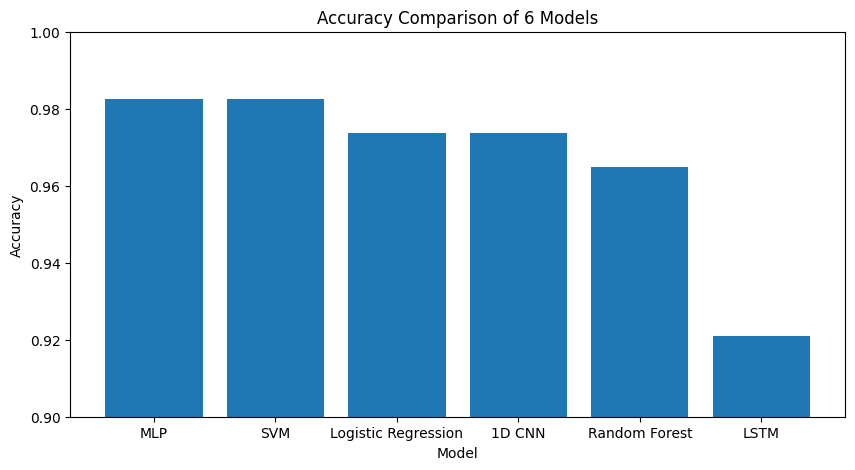

In [11]:


# ==========================================
# 11. Comparison Table
# ==========================================
comparison = pd.DataFrame({
    "Model": [x[0] for x in models_results],
    "Accuracy": [x[1] for x in models_results]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print("\n========== Final Model Comparison ==========")
print(comparison)

plt.figure(figsize=(10, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Accuracy Comparison of 6 Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)
plt.show()

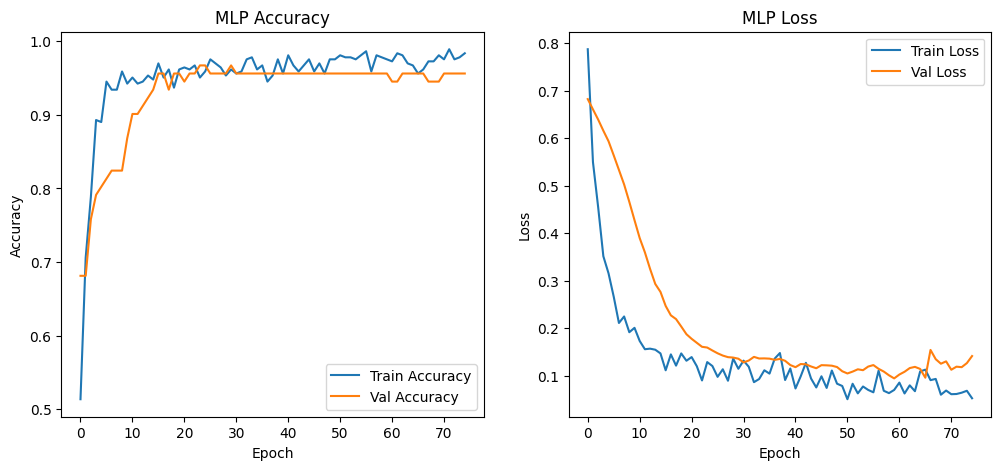

In [12]:


# ==========================================
# 12. Plot Training History for MLP
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

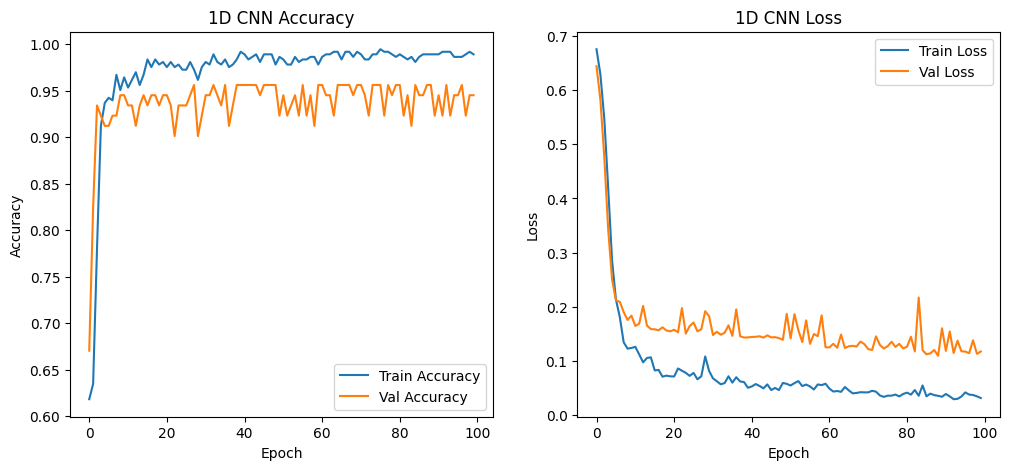

In [13]:


# ==========================================
# 13. Plot Training History for CNN
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1D CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1D CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

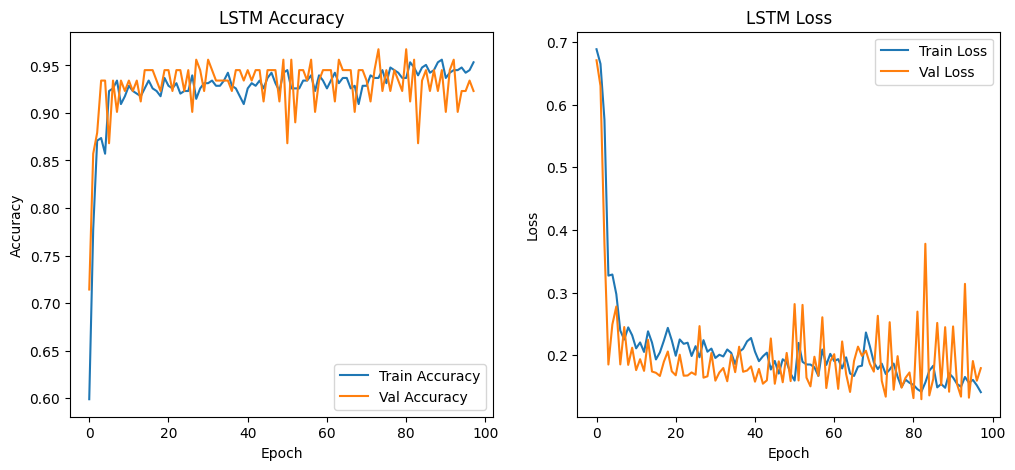

In [14]:


# ==========================================
# 14. Plot Training History for LSTM
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()